In [1]:

import sys
import importlib

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

import ezdxf

Lecture du DXF

In [21]:
import sys
import ezdxf

try:
    doc = ezdxf.readfile(r"C:\Users\mvm\open3d_vision\data\25-GO1837-CAD-1 ind A_new.dxf")
except IOError:
    print(f"Not a DXF file or a generic I/O error.")
    sys.exit(1)
except ezdxf.DXFStructureError:
    print(f"Invalid or corrupted DXF file.")
    sys.exit(2)

In [22]:
msp = doc.modelspace()


In [23]:
# helper function
def print_entity(e):
    print("LINE on layer: %s\n" % e.dxf.layer)
    print("start point: %s\n" % e.dxf.start)
    print("end point: %s\n" % e.dxf.end)
    print("lineweight: %s\n" % e.dxf.lineweight)

# iterate over all entities in modelspace
msp = doc.modelspace()
for e in msp:
    if e.dxftype() == "LINE":
        print_entity(e)

# entity query for all LINE entities in modelspace
for e in msp.query("LINE"):
    print_entity(e)

LINE on layer: LIMITE PARCELLAIRE

start point: (87923.333421, 101493.672646, 0.0)

end point: (87928.224212, 101492.473508, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87917.788227, 101442.491889, 0.0)

end point: (87916.815417, 101442.133421, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87930.580064, 101447.20559, 0.0)

end point: (87917.788227, 101442.491889, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87928.224212, 101492.473508, 0.0)

end point: (87933.840401, 101491.096565, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87942.770384, 101488.889497, 0.0)

end point: (87944.74138, 101488.402481, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87933.840401, 101491.096565, 0.0)

end point: (87942.770384, 101488.889497, 0.0)

lineweight: -1

LINE on layer: LIMITE PARCELLAIRE

start point: (87934.266074, 101448.553562, 0.0)

end point: (87942.770384, 101488.889

In [24]:
lines = msp.query('LINE')

In [6]:

print(type(lines[0]))

<class 'ezdxf.entities.line.Line'>


In [26]:
def process_dxf_file(dxf_file_path):
    doc = ezdxf.readfile(dxf_file_path)
    msp = doc.modelspace()
    
    # here, we take everything '*' in 'Conc A Line' layer
    bridge_boundary_objs = msp.query("*[layer=='COUPE']")
        
    for bb in bridge_boundary_objs:
        # there is LINE AND LWPOLYLINE; 
        # LINE is the legend, LWPOLYLINE is the actual bridge shape
        if bb.dxftype() != "LWPOLYLINE": continue
        bridge_boundary = bb.get_points('xy')
        print("bb: ",bb)
    cl2_objs = msp.query("*[layer=='COUPE']")
    cl2_polys = []
    for cl2 in cl2_objs:
        print("cl2: ",type(cl2))
        if cl2.dxftype() != "LWPOLYLINE": print(cl2.dxftype()); continue
        if any(f != l for f, l in zip(cl2[0], cl2[-1])): cl2.append(cl2[0]) 
        cl2_polys.append(cl2.get_points('xy'))
    
    cl3_objs = msp.query("*[layer=='COUPE']")
    cl3_polys = []
    for cl3 in cl3_objs:
        if cl3.dxftype() != "LWPOLYLINE": print(cl3.dxftype()); continue
        if any(f != l for f, l in zip(cl3[0], cl3[-1])): cl3.append(cl3[0]) 
        cl3_polys.append(cl3.get_points('xy'))

    return bridge_boundary, cl2_polys, cl3_polys

In [27]:
bridge_boundary_objs = msp.query("*[layer=='LIMITE PARCELLAIRE']")
i=0
for bb in bridge_boundary_objs:
    i+=1
    print(bb)
    print(type(bb))
    print(bb.dxf.start)
    print(bb.dxf.end)
    print(bb.dxf.lineweight)
    print(bb.dxf.layer)
    print(bb.dxf.color)
    print(bb.dxf.linetype)
    print(bb.dxf.linetype)
    if(i>10): break


LINE(#14F8B)
<class 'ezdxf.entities.line.Line'>
(87923.333421, 101493.672646, 0.0)
(87928.224212, 101492.473508, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F8D)
<class 'ezdxf.entities.line.Line'>
(87917.788227, 101442.491889, 0.0)
(87916.815417, 101442.133421, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F8E)
<class 'ezdxf.entities.line.Line'>
(87930.580064, 101447.20559, 0.0)
(87917.788227, 101442.491889, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F8F)
<class 'ezdxf.entities.line.Line'>
(87928.224212, 101492.473508, 0.0)
(87933.840401, 101491.096565, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F90)
<class 'ezdxf.entities.line.Line'>
(87942.770384, 101488.889497, 0.0)
(87944.74138, 101488.402481, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F91)
<class 'ezdxf.entities.line.Line'>
(87933.840401, 101491.096565, 0.0)
(87942.770384, 101488.889497, 0.0)
-1
LIMITE PARCELLAIRE
256
BYLAYER
BYLAYER
LINE(#14F92)
<class 'ezdxf.entities.line.L

In [28]:
dxf_file_path = r"C:\Users\mvm\open3d_vision\data\25-GO1837-CAD-1 ind A.dxf"
bridge_boundary, cl2, cl3 = process_dxf_file(dxf_file_path)

bb:  LWPOLYLINE(#3C248)
bb:  LWPOLYLINE(#3C249)
bb:  LWPOLYLINE(#3C24A)
bb:  LWPOLYLINE(#3C24B)
bb:  LWPOLYLINE(#3C25C)
bb:  LWPOLYLINE(#3C265)
bb:  LWPOLYLINE(#3C26B)
bb:  LWPOLYLINE(#3C271)
bb:  LWPOLYLINE(#3C276)
bb:  LWPOLYLINE(#3C277)
bb:  LWPOLYLINE(#3C28A)
bb:  LWPOLYLINE(#3C28B)
bb:  LWPOLYLINE(#3C28C)
bb:  LWPOLYLINE(#3C2B7)
bb:  LWPOLYLINE(#3C453)
bb:  LWPOLYLINE(#3C45E)
bb:  LWPOLYLINE(#3C4B4)
bb:  LWPOLYLINE(#3C4B5)
bb:  LWPOLYLINE(#3C4B6)
bb:  LWPOLYLINE(#3C4B7)
bb:  LWPOLYLINE(#3C4B8)
bb:  LWPOLYLINE(#3C4B9)
bb:  LWPOLYLINE(#3C4DA)
bb:  LWPOLYLINE(#3C4DC)
bb:  LWPOLYLINE(#3C4DD)
bb:  LWPOLYLINE(#3C4DE)
bb:  LWPOLYLINE(#3C500)
bb:  LWPOLYLINE(#3C501)
bb:  LWPOLYLINE(#3C502)
bb:  LWPOLYLINE(#3C52A)
bb:  LWPOLYLINE(#3C6DA)
bb:  LWPOLYLINE(#3C6DB)
bb:  LWPOLYLINE(#3C6E8)
bb:  LWPOLYLINE(#3C80A)
bb:  LWPOLYLINE(#3C80E)
bb:  LWPOLYLINE(#3C967)
bb:  LWPOLYLINE(#3C968)
bb:  LWPOLYLINE(#3C969)
bb:  LWPOLYLINE(#3C96A)
bb:  LWPOLYLINE(#3C9C0)
bb:  LWPOLYLINE(#3C9C5)
bb:  LWPOLYLINE(

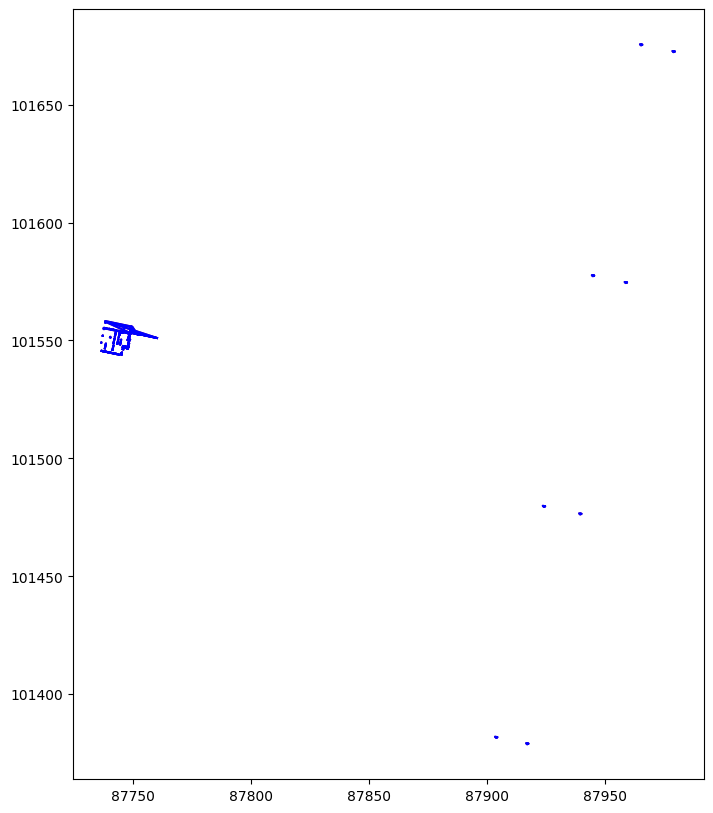

In [29]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Bridge boundary
x, y = zip(*bridge_boundary)
ax.plot(x, y, color="green", linewidth=1.0)

# cl2
for cl2_ in cl2:
    coords = np.array(cl2_)
    ax.plot(coords[:, 0], coords[:, 1], color="purple")

# cl3
for cl3_ in cl3:
    coords = np.array(cl3_)
    ax.plot(coords[:, 0], coords[:, 1], color="blue")

ax.set_aspect("equal")
plt.show()


In [30]:

def extract_inserts(dxf_file_path):
    doc = ezdxf.readfile(dxf_file_path)
    msp = doc.modelspace()
    
    # here, we take all INSERT in 'dim (wt 1)' layer
    inserts = msp.query("INSERT[layer=='dim (wt 1)']")
    print(f"the number of inserts : {len(inserts)}\n")
    
    # by dissecting the `inserts` here, we know that
    # they contain a circle, several lines and an arc
    print (inserts[0].virtual_entities())
    
    # from visual inspection, we know the center of the 
    # circle (the second element) is the location of 
    # these markers
    def get_insert_info(ins):
        xscale, yscale, rotation = ins.dxf.xscale, ins.dxf.yscale, ins.dxf.rotation
        entities = list(ins.virtual_entities())
        circle = entities[2]
        x, y = circle.dxf.center.x, circle.dxf.center.y
        return {
            "x": x,
            "y": y,
            "xscale": xscale,
            "yscale": yscale,
            "rotation": rotation,
        }
      
    insert_info = [get_insert_info(ins) for ins in inserts]
    return insert_info

In [31]:
dxf_file_path = r"C:\Users\mvm\open3d_vision\data\25-GO1837-CAD-1 ind A.dxf"
insert_info = extract_inserts(dxf_file_path)
df = pd.DataFrame(insert_info)
df.head()

the number of inserts : 0



IndexError: list index out of range

Essai chagpt

In [38]:
import ezdxf

doc = ezdxf.readfile(r"C:\Users\mvm\open3d_vision\data\25-GO1837-CAD-1 ind A_new.dxf")
msp = doc.modelspace()

lines = []
polylines = []

for e in msp:
    if e.dxftype() == "LINE":
        lines.append([
            (e.dxf.start.x, e.dxf.start.y),
            (e.dxf.end.x, e.dxf.end.y)
        ])
    elif e.dxftype() in ("LWPOLYLINE", "POLYLINE"):
        polylines.append([(p[0], p[1]) for p in e.get_points()])


In [39]:
from shapely.geometry import LineString, Polygon
from shapely.ops import unary_union


In [40]:
wall_thickness = 0.2  # mètres

wall_geoms = []

for line in lines:
    ls = LineString(line)
    wall_geoms.append(
        ls.buffer(
            wall_thickness / 2,
            cap_style=2,
            join_style=2
        )
    )

walls_2d = unary_union(wall_geoms)
walls_2d = walls_2d.buffer(0)  # nettoyage topo


In [41]:
room_polygons = []

for pl in polylines:
    if pl[0] == pl[-1] and len(pl) > 3:
        room_polygons.append(Polygon(pl))


In [42]:
import trimesh
from shapely.geometry import Polygon, MultiPolygon

WALL_HEIGHT = 2.7
wall_meshes = []

if walls_2d.geom_type == "Polygon":
    wall_meshes.append(
        trimesh.creation.extrude_polygon(
            walls_2d,
            height=WALL_HEIGHT,
            engine="triangle"
        )
    )

if walls_2d.geom_type == "MultiPolygon":
    for poly in walls_2d.geoms:
        if poly.area < 1e-4:
            continue  # ignore les micro-polygones

        mesh = trimesh.creation.extrude_polygon(
            poly,
            height=WALL_HEIGHT,
            engine="earcut"
        )
        wall_meshes.append(mesh)


In [18]:
print(type(wall_meshes))
print(type(wall_meshes[0]))

<class 'list'>
<class 'trimesh.base.Trimesh'>


In [19]:
print(len(wall_meshes))

229


In [43]:
import trimesh

scene = trimesh.Scene()
scene.add_geometry(wall_meshes[0])
scene.add_geometry(wall_meshes[1])
scene.add_geometry(wall_meshes[2])

scene.add_geometry(wall_meshes[3])
scene.add_geometry(wall_meshes[4])
scene.add_geometry(wall_meshes[5])
scene.add_geometry(wall_meshes[6:228])
scene.show()
